# BOX COZ TRANSFORMATION

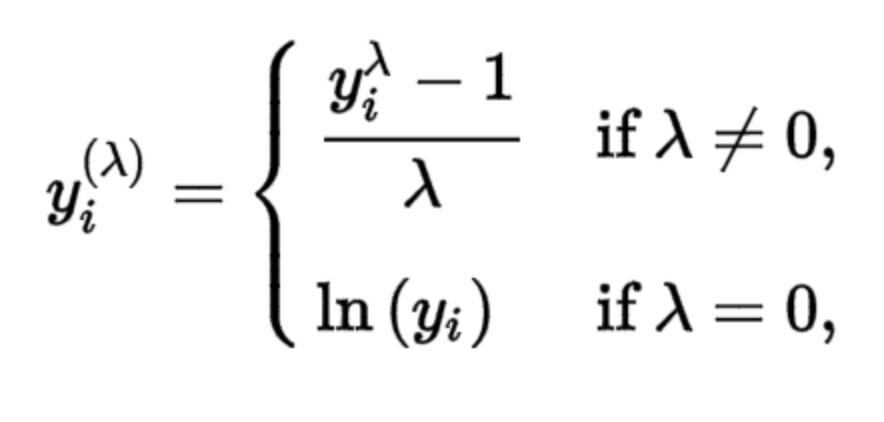

the exponent here is lambda which varies [-5,5], in process of searching we examin all values of lambda, finally we select the optimal value which result in best approximation of normal distribution for ur variable

2 methods to ifnd this:

* Maximum likelyhood
* bayesian statistic


Limitation:

strictly applicable for positive numbers only(n>0)

solution: yeo - johnson transform (-ve and 0 too)

class:PowerTransformer

# Yeo - Jhonson transformation

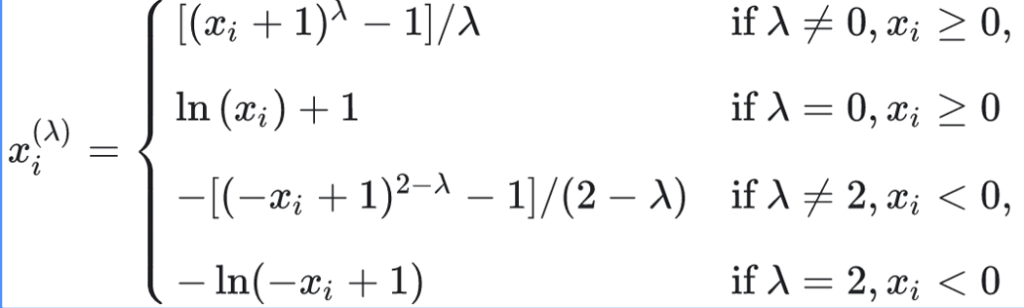

# **Begin**

In [95]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import PowerTransformer

In [96]:
df = pd.read_csv('../Data sets/concrete_data.csv')

# Data overview

In [97]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


#### checking if there are any missing values

In [98]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

#### Checking if there are any negative values coz of the property of box-cox: NO NEGATIVE AND ZERO

In [99]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


* No -ve **BUT** zeros are present(Blast Furnace Slag, Fly Ash)

In [100]:
x = df.drop(columns=['Strength'])
y = df['Strength']

In [101]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [102]:
L = LinearRegression()

L.fit(X_train,Y_train)         

pred = L.predict(X_test)
C_pred = cross_val_score(L,x,y,scoring='r2')

print(r2_score(Y_test,pred))
print(f'{np.mean(C_pred)*100}')

0.6275531792314848
46.099404916628636


* We used cross_val_score to find the actual accuracy

## plotting `distplot` & `QQ plot` for all columns without any transformation

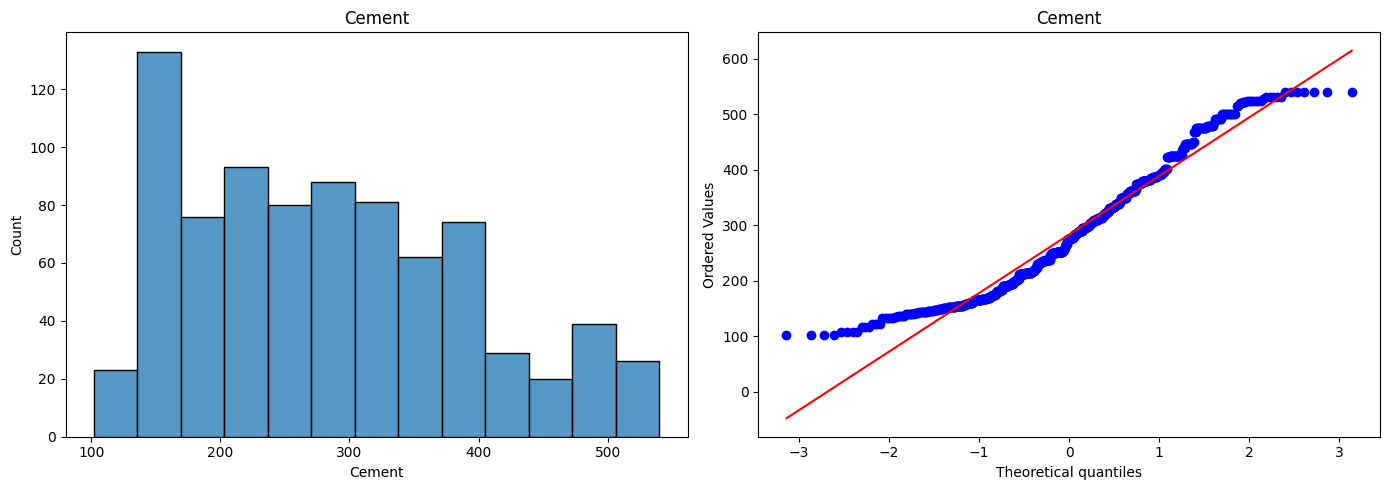

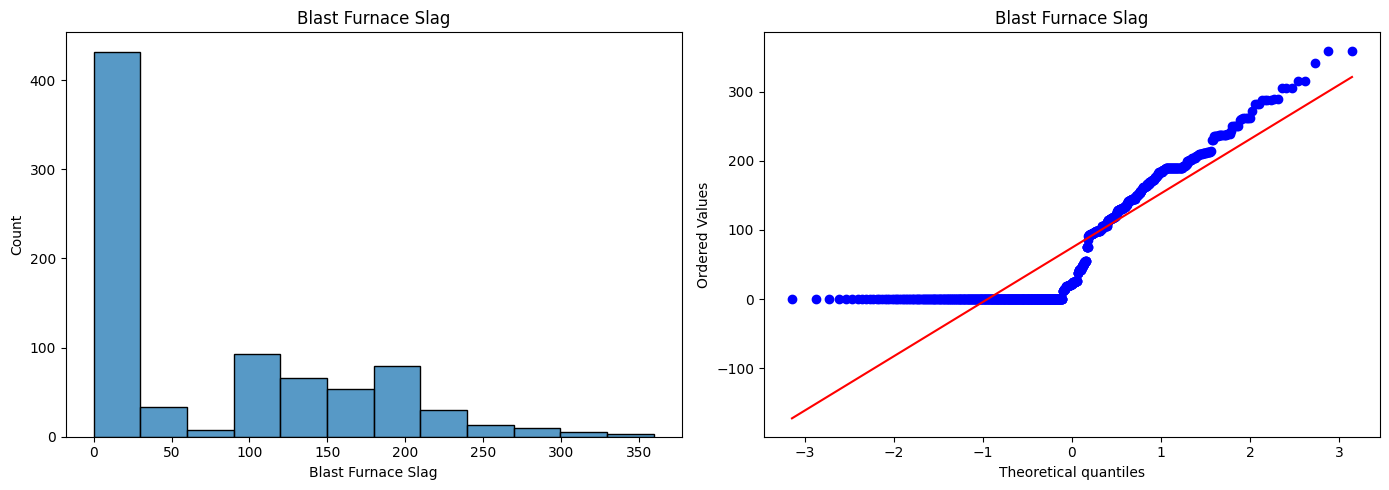

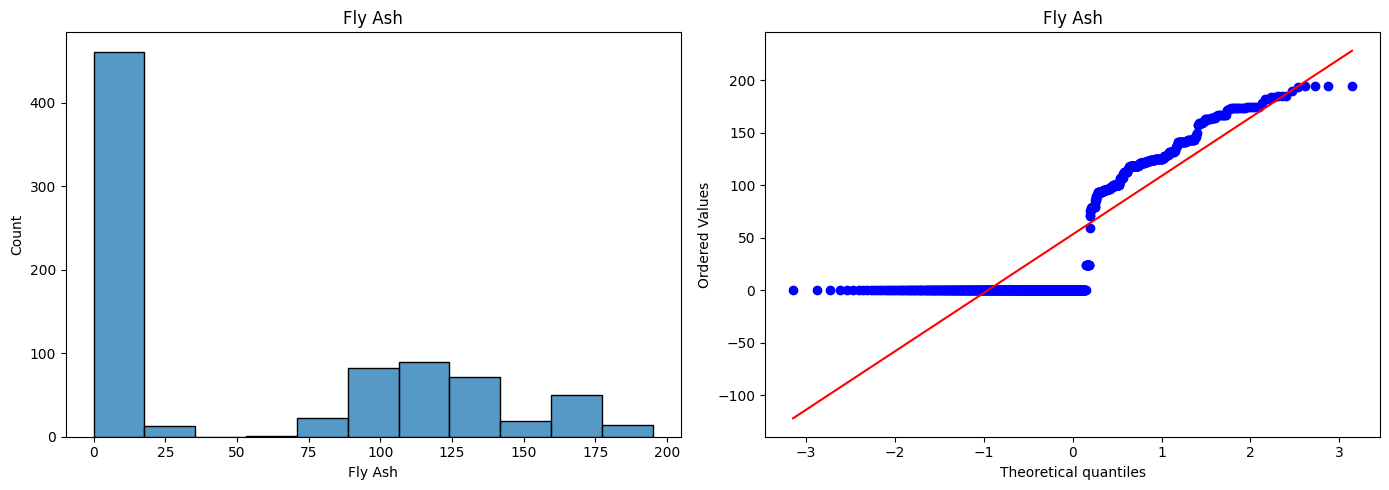

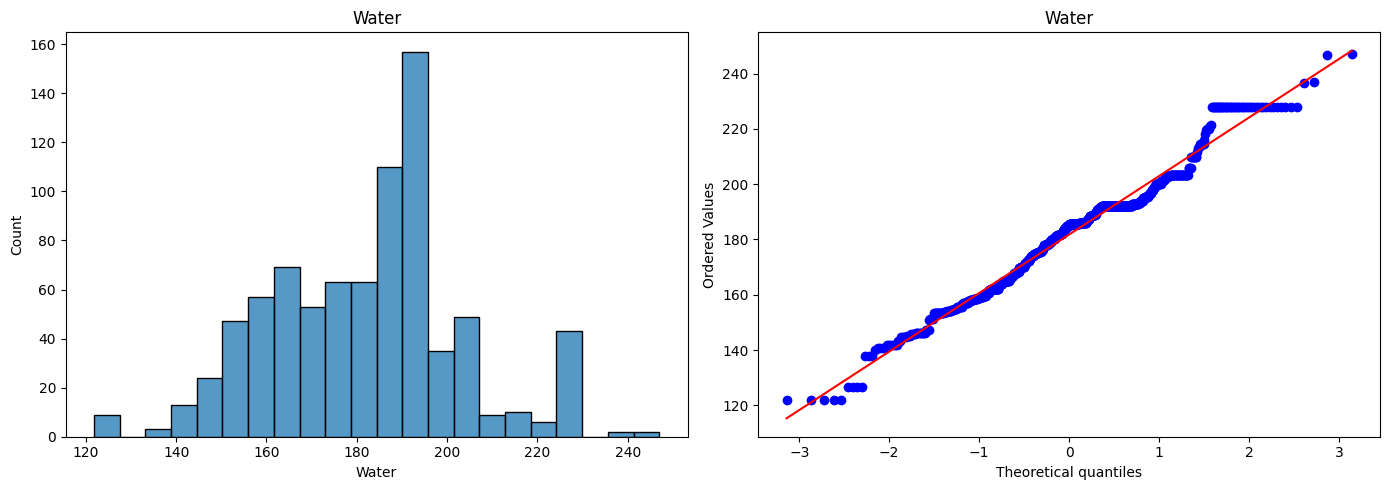

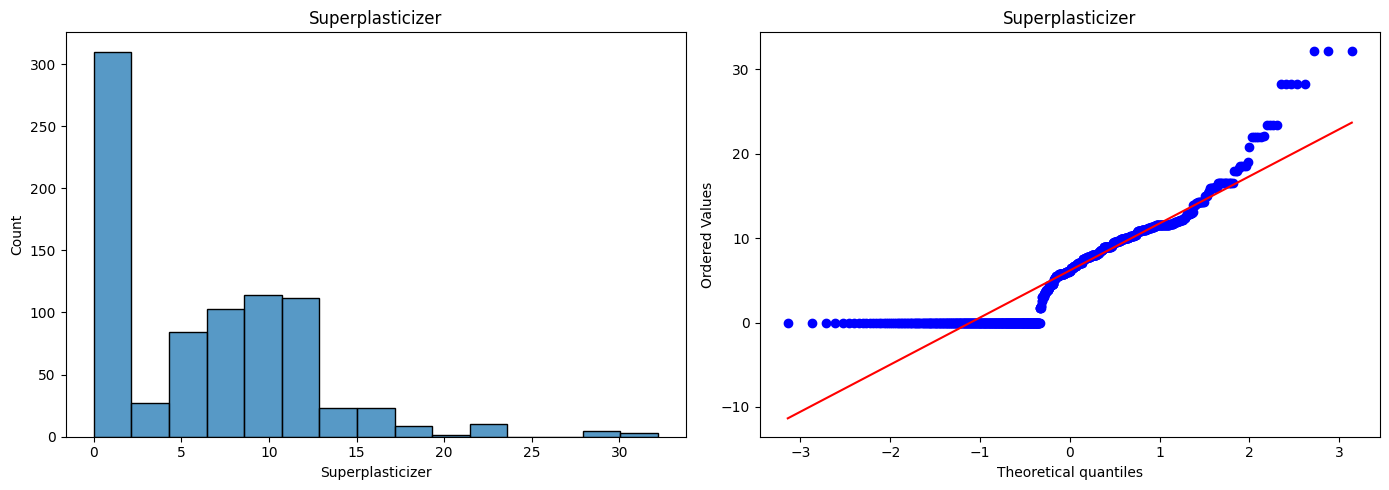

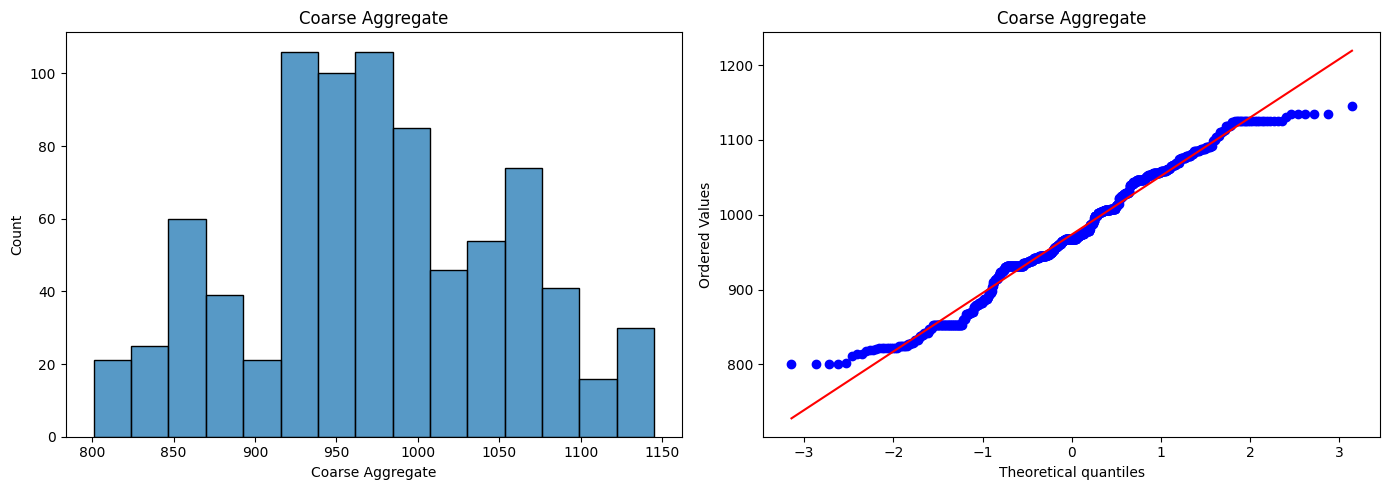

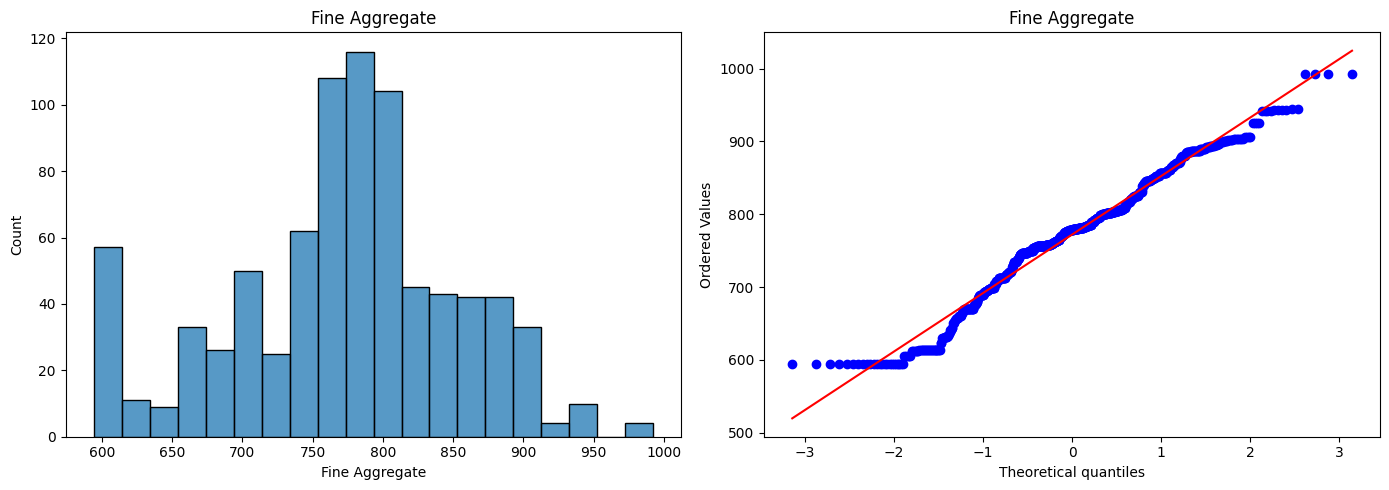

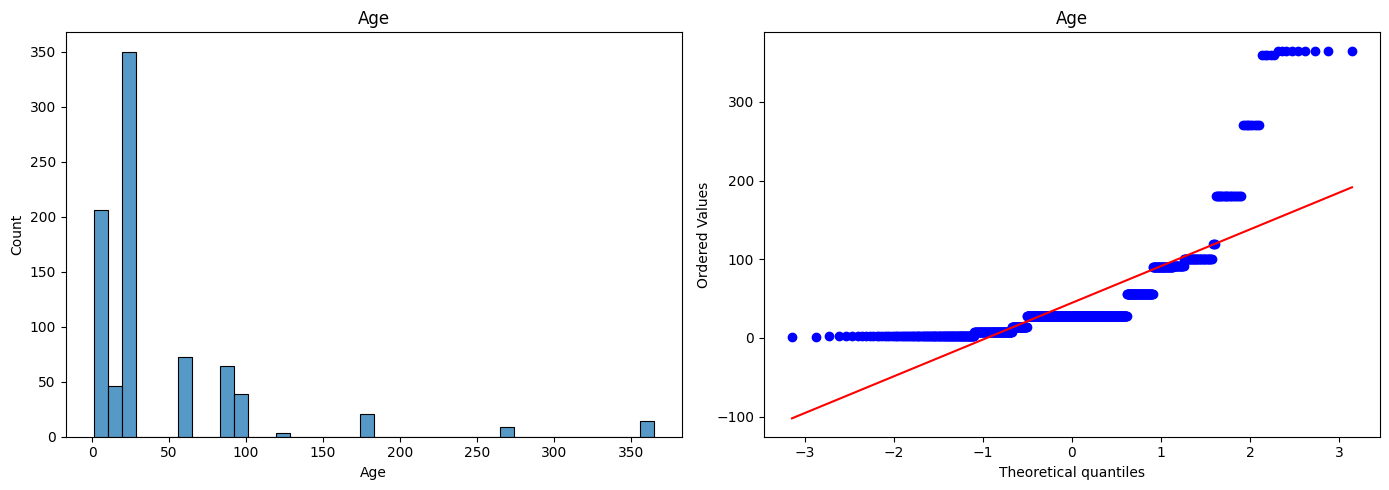

In [103]:
for col in X_train.columns:
    #common
    fig, axes = plt.subplots(1,2, figsize=(14, 5))
    #histogram
    sns.histplot(X_train[col],ax=axes[0])
    axes[0].set_title(col)

    #qq plot
    stats.probplot(X_train[col], dist='norm', plot=plt)
    axes[1].set_title(col)

    #takes less space
    plt.tight_layout()

# Applying Box-Cox transformation

In [104]:
PT = PowerTransformer(method='box-cox')

X_train_transformed = PT.fit_transform(X_train+0.00000000001)
X_test_transformed = PT.transform(X_test+0.00000000001)

In [105]:
L.fit(X_train_transformed,Y_train)

pred = L.predict(X_test_transformed)

r2_score(pred,Y_test)

0.7591050180715344

In [106]:
print(np.mean(cross_val_score(L,X_train_transformed,Y_train,scoring='r2'))*100)

79.19648516416329


## Distplot and qq plot after box-cox

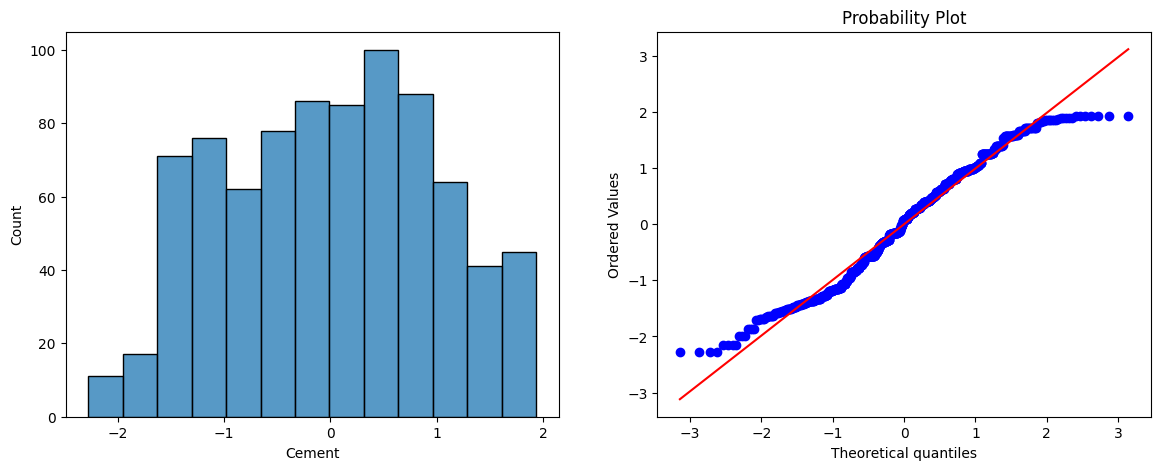

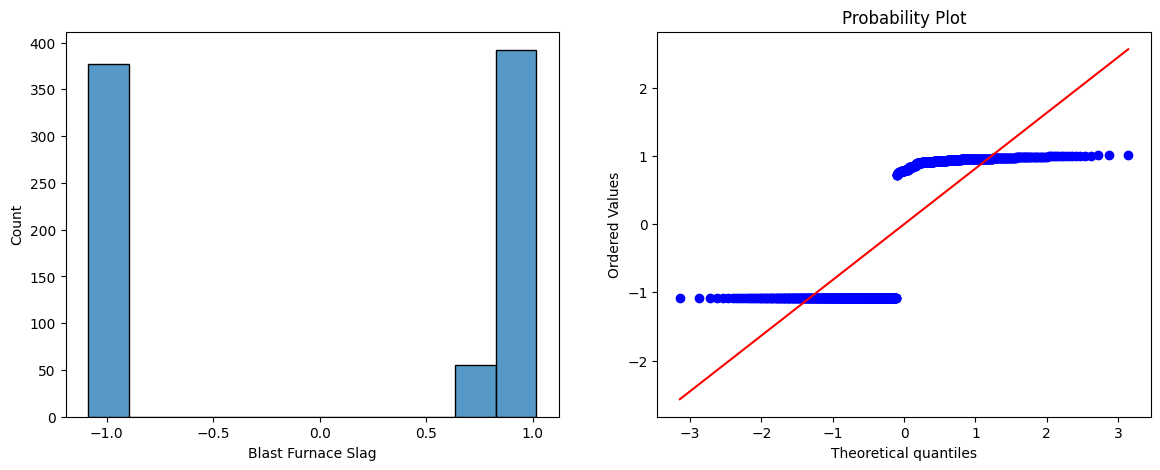

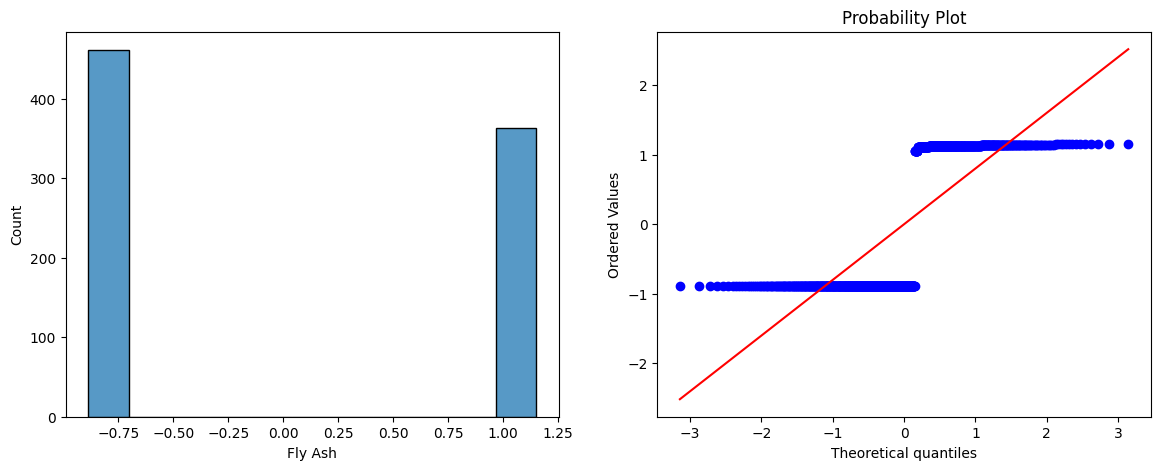

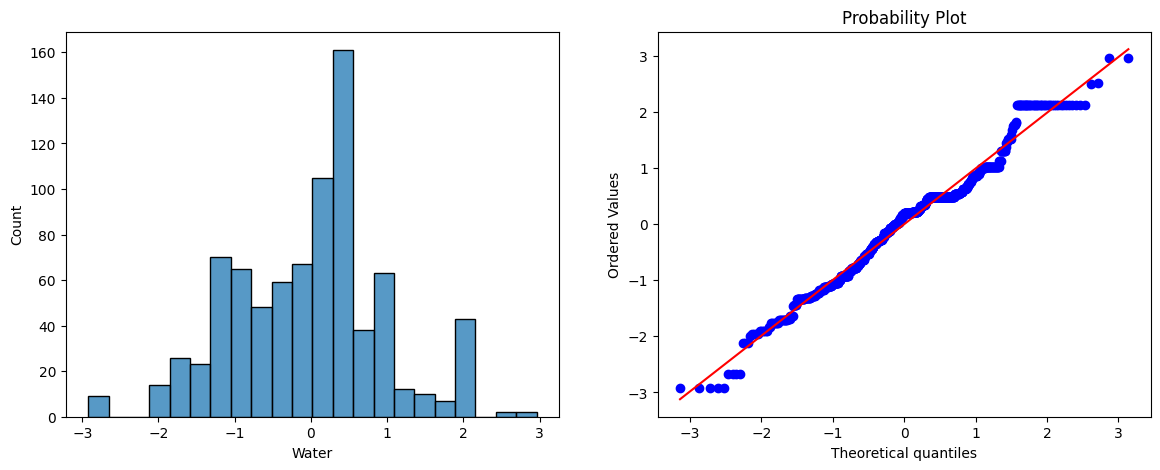

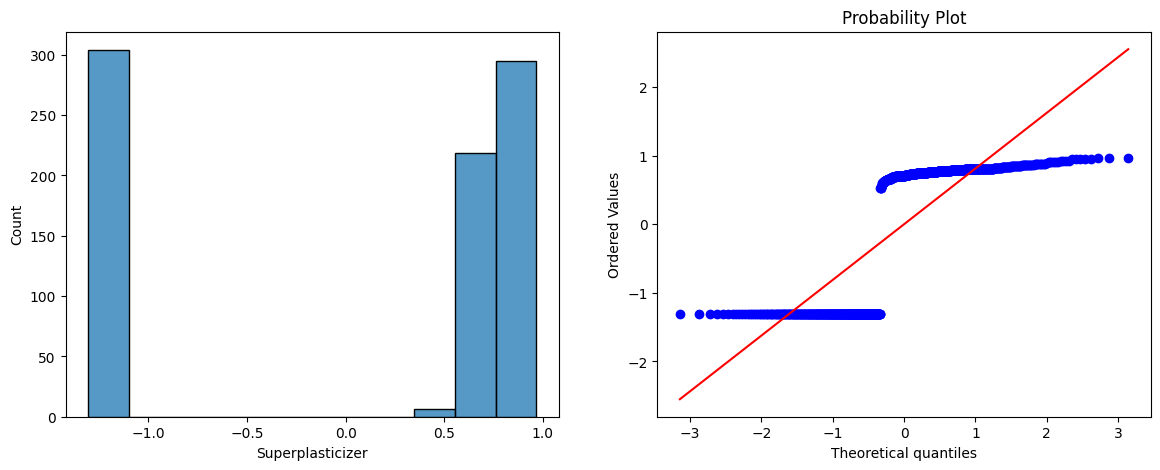

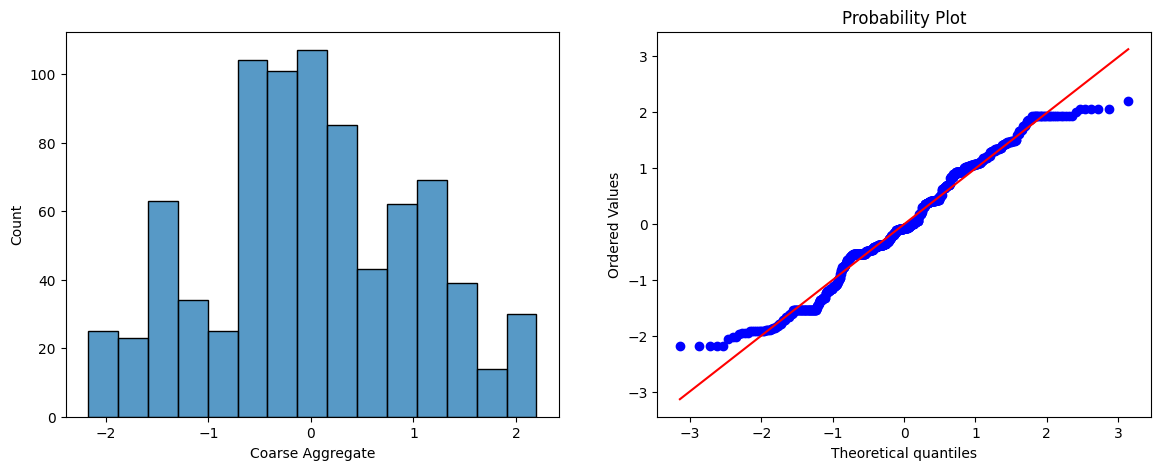

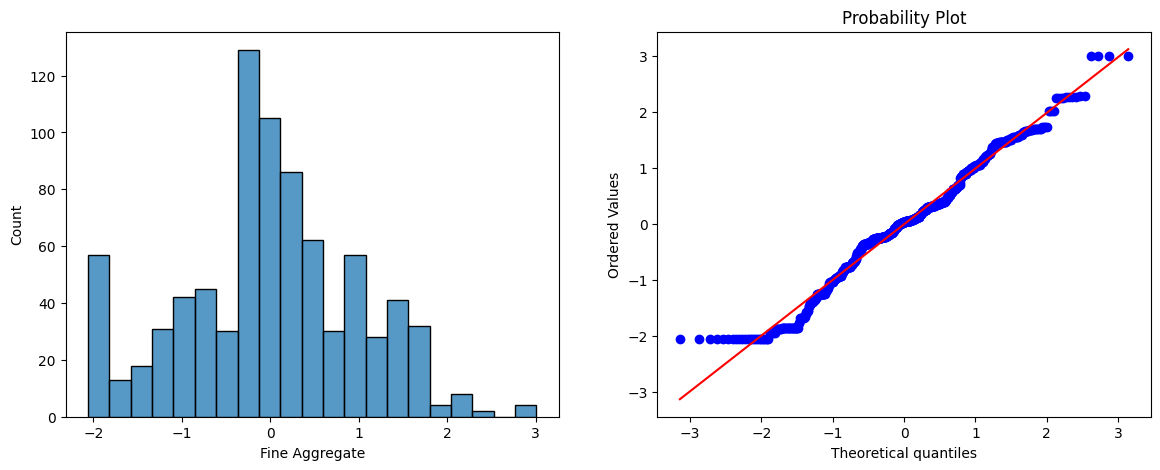

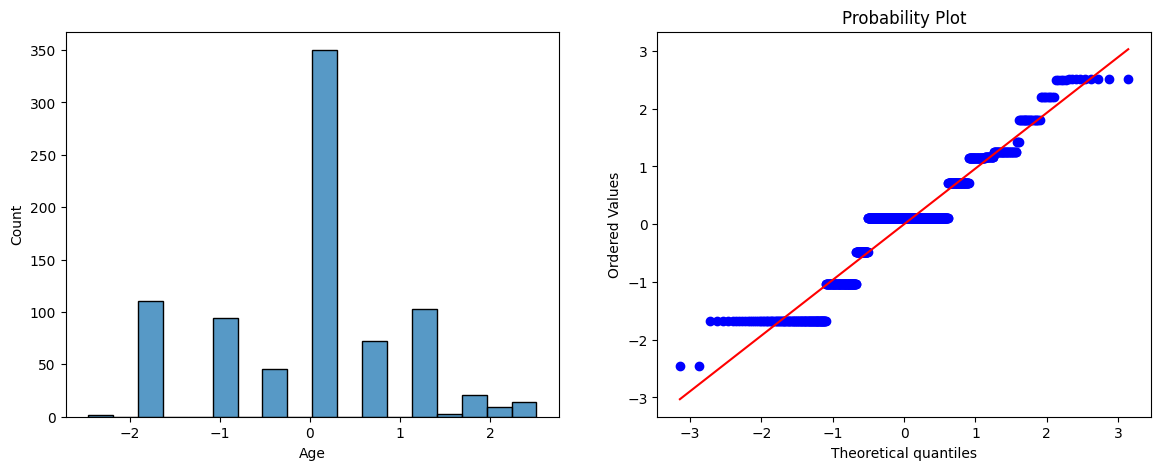

In [107]:
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
for col in X_train_transformed.columns:
    fig, axes = plt.subplots(1,2, figsize=(14,5))

    sns.histplot(X_train_transformed[col], ax=axes[0])

    stats.probplot(X_train_transformed[col], dist='norm', plot=plt)

# Yeo - johnson transform